# ATiG 2026: LT-FH exercise using ltpred

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bvilhjal/ATIG_2026/blob/main/teaching_days/2026-09-24/LTFH/LTFH_exercise_answers.ipynb)

*Worked answers.* Each answer follows its question; code cells are filled in.

## What you will learn

You score a simulated register with [ltpred](https://github.com/bvilhjal/ltpred)'s
family-history method, LT-FH++, and compare the scores with the true genetic liability,
which a simulation lets you see. You make six plots along the way.

- **In class (about an hour):** Part 0 (10 min) builds and plots the scores; **A** (20 min):
  what a wrong heritability h² does; **B** (30 min): how well the score predicts who is
  diagnosed later.
- **Homework:** **C** the score against a yes/no family history; **D** heritability from
  parents and children; **E** the two scales on which h² is reported.

Work in pairs, ideally one person with a biology and one with a bioinformatics
background. Questions marked **Discuss** are for talking through together.

**Background.** LT-FH ([Hujoel et al. 2020](https://doi.org/10.1038/s41588-020-0613-6))
turns relatives' diagnoses into an estimate of a person's genetic liability; LT-FH++
([Pedersen et al. 2022](https://doi.org/10.1016/j.ajhg.2022.01.009)) adds age of onset
through age-dependent thresholds. ltpred computes it with the Pearson–Aitken method of
PA-FGRS ([Krebs et al. 2024](https://doi.org/10.1016/j.ajhg.2024.09.009)).

## The idea in five sentences

1. Everyone has a **liability** to the disease: an unobserved quantity that adds up a
   genetic part and an environmental part and follows a bell curve in the population.
2. People whose liability passes a **threshold** get the disease. In LT-FH++ the threshold
   falls with age, so the higher your liability, the earlier you are diagnosed.
3. **Heritability h²** is the share of liability variance that is genetic. Relatives share
   genes, so their diagnoses carry information about your genetic liability.
4. **LT-FH++** turns the relatives' diagnoses and ages into a best estimate of your genetic
   liability (the *score*), with a measure of its uncertainty.
5. Real data never reveal the true genetic liability. A simulation does, so here you can
   check how good the score is.

| Term | Meaning here |
|---|---|
| liability | the unobserved disease predisposition; genetic part `g` plus the rest |
| h² (liability scale) | share of liability variance due to additive genes; 0.5 here |
| K, prevalence | fraction who get the disease in a lifetime; 0.10 here |
| cumulative incidence | fraction diagnosed by a given age; rises from 0 to K |
| score, posterior mean | best estimate of `g` given the family's records |
| AUC | chance that a random case scores higher than a random non-case (0.5 = coin flip) |
| calibration slope | slope of the truth regressed on the score; 1 means the score's scale is right |
| tetrachoric correlation | correlation of two liabilities, inferred from two yes/no variables |
| observed scale | h² measured on the 0/1 diagnosis itself instead of on the liability |

## How to use this notebook

1. Click **Open in Colab** above, then **File → Save a copy in Drive** and work in your copy.
2. Run the cells in order with **Shift+Enter**. If Colab restarts, start again from the top.
3. Where a cell has `...`, replace it with one expression; the comment says what. Every
   plot is ready to run once its `...` is filled. **Checkpoints** say what you should see.

| Name | What it is |
|---|---|
| `reg` | the simulated register (one row per person) |
| `g` | each person's true genetic liability |
| `est` | everyone's score, using all records |
| `free40` | True for people still undiagnosed at 40 |
| `est40`, `var40` | the score as known at 40, and its uncertainty, for those people |
| `score(h2)` | rescores everyone under an assumed h² |

### The Python you need

| Code | What it does |
|---|---|
| `x[mask]` | keeps the entries of `x` where the True/False array `mask` is True |
| `a & b`, `~a` | True where both are True; True where `a` is False |
| `x.mean()`, `x.sum()` | average and total; on True/False arrays, the share and count of True |
| `[f(x) for x in xs]` | a list with `f` applied to each element of `xs` |
| `ax.scatter(x, y)`, `ax.hist(x)`, `ax.bar(names, values)`, `ax.plot(x, y)` | the four plots you will make |

## Setup

The first cell installs ltpred; the second loads it, loads matplotlib for plotting and
defines two small helpers, `corr` and `auc`. (On your own computer instead of Colab? See
the [setup page](https://bvilhjal.github.io/ATIG_2026/setup.html).)

In [ ]:
%pip install -q git+https://github.com/bvilhjal/ltpred@v0.7.1     # installs ltpred (about 30 s)

In [1]:
import numpy as np
from scipy.stats import norm, rankdata
import matplotlib.pyplot as plt

import ltpred
from ltpred import simulate_pedigree, simulate_register_liabilities, estimate_liabilities
print("ltpred", ltpred.__version__)


def corr(x, y):
    """Pearson correlation of two arrays."""
    return np.corrcoef(x, y)[0, 1]


def auc(score, case):
    """AUC: the chance that a random case scores above a random non-case.

    Computed from ranks (the Mann-Whitney statistic); `case` is a boolean array."""
    r = rankdata(score)
    n1, n0 = case.sum(), (~case).sum()
    return (r[case].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

ltpred 0.7.1


## Part 0. A register where the truth is known

The cell below simulates three generations of families (5,075 people). Each person gets
a liability: a genetic part `g` with variance h² = 0.5 plus a non-genetic part. A person
is diagnosed at the age their liability crosses an age-dependent threshold (the LT-FH++
model), and everyone is followed to age 70.

| Field | Meaning |
|---|---|
| `reg.ids`, `reg.father`, `reg.mother` | the pedigree |
| `reg.status` | diagnosed by age 70 (True/False) |
| `reg.age` | age at diagnosis, or 70 for the undiagnosed |
| `reg.onset`, `reg.birth_time` | age at onset (`inf` if never) and calendar time of birth |
| `reg.genetic` | the true genetic liability, stored as `g` |

In [2]:
H2 = 0.5                                    # true liability-scale heritability
K = 0.10                                    # lifetime prevalence
AGES = np.arange(0, 121.0)                  # ages 0, 1, ..., 120
CIP = K / (1 + np.exp((60 - AGES) / 8))     # cumulative incidence by age: half of K by age 60

ids, father, mother = simulate_pedigree(np.random.default_rng(1), n_founder_pairs=500, gens=2)
reg = simulate_register_liabilities(np.random.default_rng(1), ids, father, mother,
                                    h2=H2, cip_ages=AGES, cip_values=CIP, eval_age=70)
g = reg.genetic                             # the truth, known only because we simulated it

print(f"{len(reg.ids)} people, {reg.status.sum()} diagnosed by age 70 ({reg.status.mean():.1%})")
print(f"var(g) = {g.var():.3f}   (target {H2})")

5075 people, 366 diagnosed by age 70 (7.2%)
var(g) = 0.493   (target 0.5)


**Checkpoint.** 5,075 people, 366 diagnosed (7.2%), and var(g) close to 0.5.

### The scorer in one call

`estimate_liabilities` takes the pedigree, everyone's diagnosis and age, the incidence
curve and h², and returns each person's score (`.est`) with its uncertainty (`.var`).
The comments explain each argument.

In [3]:
scores = estimate_liabilities(
    reg.ids, reg.father, reg.mother,          # the pedigree: who is whose parent
    probands=reg.ids,                         # whom to score: everyone
    status=reg.status, age=reg.age,           # diagnosed by 70? age at diagnosis or at 70
    cip_ages=AGES, cip_values=CIP, k_pop=K,   # incidence curve: turns an age into a liability threshold
    h2=H2,                                    # heritability: you supply it, the scorer never estimates it
    use="gwas")                               # also use each person's own diagnosis

est, var = scores.est, scores.var
print(f"corr(score, g) = {corr(est, g):.3f}")
print(f"var(score) = {est.var():.3f}  +  mean posterior variance = {var.mean():.3f}"
      f"  =  {est.var() + var.mean():.3f}")

corr(score, g) = 0.522
var(score) = 0.129  +  mean posterior variance = 0.359  =  0.488


### The helpers used below

`score(h2)` repeats that call under any assumed h². `score_at_40(h2)` scores the people
still undiagnosed at 40 **as of their 40th birthday**, hiding their own status and every
later record: the honest setting for predicting who is diagnosed later.

In [4]:
free40 = reg.onset > 40                     # still undiagnosed on their 40th birthday


def score(h2):
    """Everyone's score from all records up to 70 (use="gwas"): (mean, variance)."""
    s = estimate_liabilities(reg.ids, reg.father, reg.mother, probands=reg.ids,
                             status=reg.status, age=reg.age,
                             cip_ages=AGES, cip_values=CIP, k_pop=K, h2=h2, use="gwas")
    return s.est, s.var


def score_at_40(h2):
    """Scores as known on each person's 40th birthday (use="prediction"), for the
    people still undiagnosed then: their own status and every later record are hidden."""
    s = estimate_liabilities(reg.ids, reg.father, reg.mother,
                             probands=[p for p, keep in zip(reg.ids, free40) if keep],
                             status=reg.status, age=reg.age,
                             cip_ages=AGES, cip_values=CIP, k_pop=K, h2=h2, use="prediction",
                             birth_time=reg.birth_time,                  # everyone's birth date
                             index_time=(reg.birth_time + 40)[free40])   # each proband's 40th birthday
    return s.est, s.var


est40, var40 = score_at_40(H2)
print(f"{free40.sum()} people undiagnosed at 40; corr(score at 40, g) = {corr(est40, g[free40]):.3f}")

5037 people undiagnosed at 40; corr(score at 40, g) = 0.278


### Q1: Plot the score against the true genetic liability.

Fill in the two arrays: the score `est` on the x-axis and the truth `g` on the y-axis.
What does a correlation of about 0.5 look like?

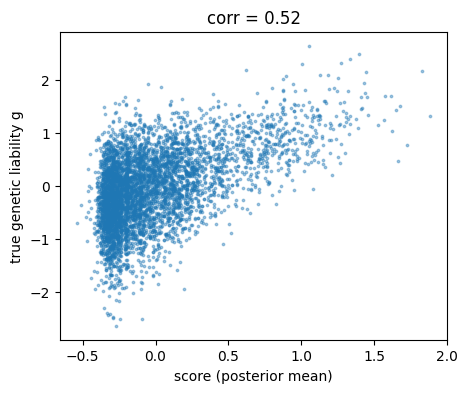

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(est, g, s=3, alpha=0.4)             # x: the score est, y: the truth g
ax.set_xlabel("score (posterior mean)")
ax.set_ylabel("true genetic liability g")
ax.set_title(f"corr = {corr(est, g):.2f}")
plt.show()

**Answer.** A broad cloud with an upward tilt: correlation 0.52. People with a high score
tend to have a high `g`, but at any score the true value still varies widely. Most scores
are small and negative: 4,226 of the 5,075 people are undiagnosed with no diagnosed
parent, and their scores average −0.14; ages and other relatives' records spread them
out. A diagnosis in the family moves the score up.

## Part A. What does a wrong h² do?

In a real analysis h² comes from outside (a twin, pedigree or SNP study) and you supply
it. Here you can pass a wrong value on purpose and compare with the truth.

### Q2: If you tell the scorer h² = 0.8 when the truth is 0.5, do the scores spread more or less? Does their ranking change?

Write down your expectation with one sentence of reasoning. Hint: h² is the share of
liability variance that is genetic, and therefore shared with relatives.

**Discuss** with your partner.

**Answer.** With h² = 0.8 the scorer believes relatives' diagnoses say more about a
person's genetic liability than they do, so every score moves further from zero: the
spread grows. The ranking barely changes, because the same records point the same way.
Q3 checks both.

### Q3: Plot the truth against the score for h² = 0.2, 0.5 and 0.8.

Each panel shows the fitted line of `g` on the score (orange) and the dashed diagonal.
Fill in the slope. A score is **calibrated** when the slope is 1: among people scored 0.3,
the true liability averages 0.3. Which assumed h² gives slope 1, and what happens to the
correlation?

h2 = 0.2: corr 0.515, slope 2.06


h2 = 0.5: corr 0.522, slope 1.02


h2 = 0.8: corr 0.519, slope 0.70


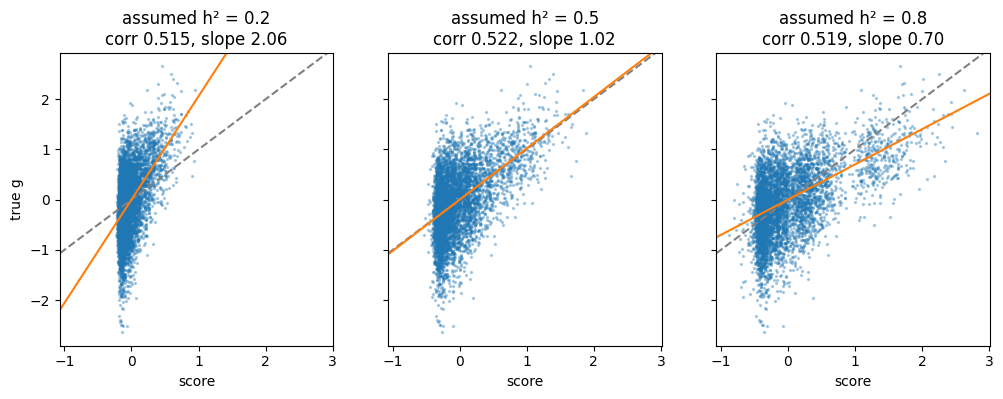

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True)
for ax, h2 in zip(axes, (0.2, 0.5, 0.8)):
    e, v = score(h2)                           # rescore everyone under this h2
    b = np.polyfit(e, g, 1)[0]                 # slope of g regressed on e
    print(f"h2 = {h2}: corr {corr(e, g):.3f}, slope {b:.2f}")
    ax.scatter(e, g, s=2, alpha=0.3)
    ax.axline((0, 0), slope=1, ls="--", color="grey")   # slope 1: calibrated
    ax.axline((0, 0), slope=b, color="C1")              # the fitted slope
    ax.set_title(f"assumed h² = {h2}\ncorr {corr(e, g):.3f}, slope {b:.2f}")
    ax.set_xlabel("score")
axes[0].set_ylabel("true g")
plt.show()

**Answer.** The correlation is 0.515, 0.522 and 0.519: the ranking hardly notices the
wrong h². The slope is 2.06, 1.02 and 0.70, and only the true h² = 0.5 lies on the
diagonal. Under 0.2 the scores are too timid (the truth moves twice as fast as the
score); under 0.8 they are too bold. A GWAS that uses the score as its phenotype needs
only the ranking; anything that reads the score's scale, such as a risk (Part B), needs
the right h².

## Part B. Who is diagnosed between 40 and 70?

![Liability thresholds at 40 and 70. Higher liability is earlier onset. People still undiagnosed at 40 are left of T40; those diagnosed by 70 have crossed T70.](https://bvilhjal.github.io/ATIG_2026/teaching_days/2026-09-24/LTFH/figures/thresholds.png)

A correlation with `g` is not the accuracy of predicting a later diagnosis. Here you use
the score at 40 (`est40`) and what happened next.

### Q4: How many of the people undiagnosed at 40 are diagnosed by 70?

`reg.status` means "diagnosed by 70" and `free40` means "undiagnosed at 40". The result
`y` must line up with `est40`, which has one entry per person in `free40`.

In [7]:
y = reg.status[free40]       # everyone in est40 was undiagnosed at 40, so "by 70" means "40 to 70"
print(f"{y.sum()} incident cases among {len(y)} people ({y.mean():.1%})")

328 incident cases among 5037 people (6.5%)


**Answer.** 328 cases among 5,037 people, 6.5%. The 38 people diagnosed before 40 are
left out: they were already cases, so scoring them and calling it a prediction would be
leakage.

### Q5: Plot the scores of the later cases and the non-cases, and compute the AUC.

Fill in the cases' scores for the histogram and `g` for the same people in the AUC.
How much do the two histograms overlap? Why is even the true `g` below AUC 1, and why is
the `use="gwas"` score (which saw each person's own diagnosis) near-perfect?

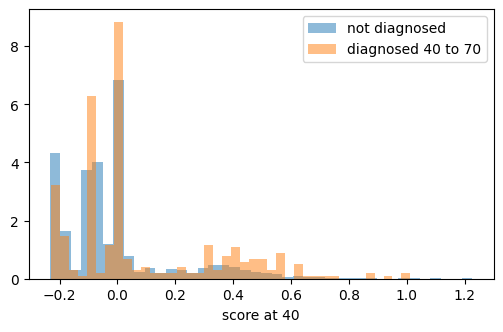

AUC score at 40        0.605
AUC true g             0.887
AUC use='gwas' score   0.995


In [8]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(est40[~y], bins=40, density=True, alpha=0.5, label="not diagnosed")
ax.hist(est40[y], bins=40, density=True, alpha=0.5, label="diagnosed 40 to 70")   # the cases' scores
ax.set_xlabel("score at 40")
ax.legend()
plt.show()

print(f"AUC score at 40        {auc(est40, y):.3f}")
print(f"AUC true g             {auc(g[free40], y):.3f}")
print(f"AUC use='gwas' score   {auc(est[free40], y):.3f}")

**Answer.** The two histograms overlap heavily: most later cases have the same small
scores as everyone else, and only a minority, with a relative diagnosed before their
40th birthday, sit in the bump around 0.3 to 0.6. The AUC of the score at 40 is 0.605.
The true `g` reaches 0.887, not 1, because diagnosis also depends on the non-genetic
half of the liability (variance 1 − h² = 0.5), which no genetic predictor can see. The
`use="gwas"` score reaches 0.995 because it contains the person's own diagnosis, which is
the outcome: that is leakage, not prediction.

### Q6: Turn the score into a risk and plot it against what happened.

Given the relatives, a person's liability is normal with mean `est40` and standard
deviation `sd`; the risk of diagnosis between 40 and 70 is the chance it lies between the
thresholds, given it is below the age-40 threshold. The cell computes that risk for you.
Fill in the mean predicted risk in each fifth of the score, then compare the bars. Does
the risk match the observed rates? What would a wrong h² do to it?

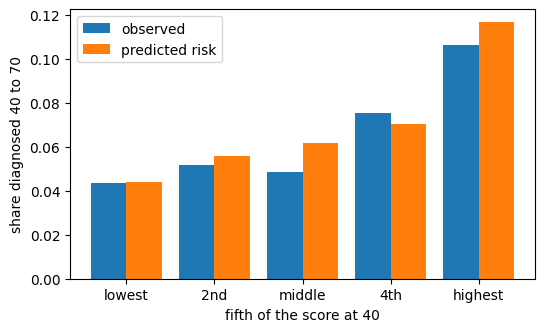

mean predicted risk 0.070   observed 0.065
  lowest fifth: observed 0.044, predicted 0.044
     2nd fifth: observed 0.052, predicted 0.056
  middle fifth: observed 0.049, predicted 0.062
     4th fifth: observed 0.075, predicted 0.070
 highest fifth: observed 0.106, predicted 0.117


In [9]:
T40, T70 = norm.isf(np.interp([40, 70], AGES, CIP))    # LT-FH++ thresholds at ages 40 and 70
sd = np.sqrt(var40 + 1 - H2)                           # spread of full liability given the relatives
below40 = norm.cdf((T40 - est40) / sd)                 # P(undiagnosed at 40)
below70 = norm.cdf((T70 - est40) / sd)                 # P(undiagnosed at 70)
risk = (below40 - below70) / below40                   # P(diagnosed 40-70 | undiagnosed at 40)

fifths = np.array_split(np.argsort(est40, kind="stable"), 5)   # lowest to highest score
observed = [y[idx].mean() for idx in fifths]                   # share diagnosed in each fifth
predicted = [risk[idx].mean() for idx in fifths]               # mean risk in each fifth

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(np.arange(5) - 0.2, observed, width=0.4, label="observed")
ax.bar(np.arange(5) + 0.2, predicted, width=0.4, label="predicted risk")
ax.set_xticks(range(5), ["lowest", "2nd", "middle", "4th", "highest"])
ax.set_xlabel("fifth of the score at 40")
ax.set_ylabel("share diagnosed 40 to 70")
ax.legend()
plt.show()
print(f"mean predicted risk {risk.mean():.3f}   observed {y.mean():.3f}")
for name, o, p in zip(("lowest", "2nd", "middle", "4th", "highest"), observed, predicted):
    print(f"{name:>8} fifth: observed {o:.3f}, predicted {p:.3f}")

**Answer.** Mean predicted risk 7.0% against 6.5% observed. By fifth the observed rate is
4.4%, 5.2%, 4.9%, 7.5% and 10.6% against predicted risks of 4.4%, 5.6%, 6.2%, 7.0% and
11.7%. Each fifth has only 44 to 107 cases, so the observed bars carry about a percentage
point of noise. The top fifth has 2.4 times the risk of the bottom one, and the middle
three are hard to tell apart: that is what an AUC of 0.6 looks like. The risk uses h²
twice (inside `var40` and as `1 - H2`), so a wrong h² would give a confidently wrong
risk.

## Part C. The score against a yes/no family history (homework)

A common shortcut is the indicator "any parent or full sibling diagnosed". The cell below
builds it twice: with follow-up to 70 (`fh`) and as known on each person's 40th birthday
(`fh40`). Run it as is.

In [10]:
row = {p: i for i, p in enumerate(reg.ids)}          # id -> row number
children = {}                                        # (father, mother) -> rows of their children
for i, (f, m) in enumerate(zip(reg.father, reg.mother)):
    if f in row and m in row:
        children.setdefault((f, m), []).append(i)


def first_degree(i):
    """Rows of person i's parents and full siblings."""
    f, m = reg.father[i], reg.mother[i]
    parents = [row[p] for p in (f, m) if p in row]
    siblings = [j for j in children.get((f, m), []) if j != i]
    return np.array(parents + siblings, dtype=int)


fdr = [first_degree(i) for i in range(len(reg.ids))]
diag_time = reg.birth_time + reg.onset               # calendar time of each diagnosis
birth40 = reg.birth_time + 40                        # calendar time of each 40th birthday

# yes/no family history: any affected parent or sibling, by 70 and by one's own 40th birthday
fh = np.array([reg.status[r].any() for r in fdr])
fh40 = np.array([(reg.status[r] & (diag_time[r] <= birth40[i])).any() for i, r in enumerate(fdr)])
print(f"family-history positive: {fh.sum()} by age 70, {fh40.sum()} at their 40th birthday")

family-history positive: 954 by age 70, 609 at their 40th birthday


### Q7: Plot how much of `g` each measure explains.

Fill in R², the squared correlation with `g`, for own status, the indicator and the
score. The last line compares the indicator known at 40 with the score at 40 as
predictors of Part B's outcome. Why is own status left out of that comparison?

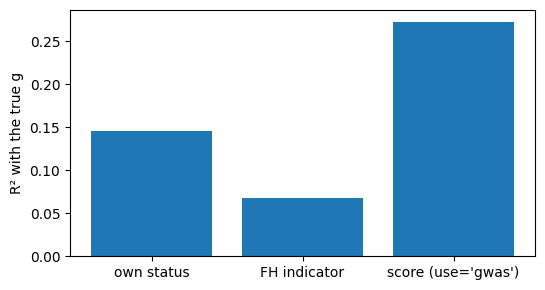

prediction at 40: AUC FH indicator 0.562, AUC score 0.605
R2: own status 0.145, FH indicator 0.068, score (use='gwas') 0.273


In [11]:
names = ["own status", "FH indicator", "score (use='gwas')"]
r2 = [corr(x, g) ** 2 for x in (reg.status, fh, est)]      # R²: the squared correlation of each with g

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(names, r2)
ax.set_ylabel("R² with the true g")
plt.show()
print(f"prediction at 40: AUC FH indicator {auc(fh40[free40], y):.3f}, AUC score {auc(est40, y):.3f}")
print("R2:", ", ".join(f"{n} {v:.3f}" for n, v in zip(names, r2)))

**Answer.** The indicator explains 6.8% of the variance of `g`, own status 14.5% and the
score 27.3%: four times the indicator, because the score also weighs each relative's age
and relationship and the person's own diagnosis. As a prediction at 40, own status is the
same for everyone (all were undiagnosed), and the AUC is 0.562 for the indicator against
0.605 for the score.

## Part D. Where does h² come from? (homework)

A quick cross-check on h²: it is about twice the **tetrachoric correlation** between
parents' and children's diagnoses, the correlation of the underlying liabilities inferred
from a 2×2 table. The cell below lists every parent–child pair; run it as is.

In [12]:
from ltpred import tetrachoric

# every parent-child pair in the register, as row numbers
pairs = [(row[p], i) for i, (f, m) in enumerate(zip(reg.father, reg.mother))
         for p in (f, m) if p in row]
par, kid = np.array(pairs).T


def table(a, b):
    """2x2 table of two True/False arrays: both, first only, second only, neither."""
    return np.array([(a & b).sum(), (a & ~b).sum(), (~a & b).sum(), (~a & ~b).sum()])

### Q8: Estimate h² from the parent–offspring pairs.

In [13]:
p_status, k_status = reg.status[par], reg.status[kid]
t = tetrachoric(p_status, k_status)
print(f"{len(par)} pairs, table {table(p_status, k_status)}")
print(f"h2 = 2 rho = {2 * t.rho:.2f} +/- {2 * t.se:.2f}   (truth {H2})")

7884 pairs, table [  90  489  460 6845]
h2 = 2 rho = 0.52 +/- 0.07   (truth 0.5)


**Answer.** h² = 0.52 ± 0.07 from 7,884 pairs. Almost all the information is in the 90
pairs where both are diagnosed.

### Q9: Why does twice the tetrachoric work here, and what would break it in a real register?

Think about the threshold, shared environment, and how the register was sampled.

**Discuss** with your partner.

**Answer.** It works when (1) everyone's status is cut at one common threshold, true here
because everyone is followed to 70; (2) the parent–offspring liability covariance is h²/2
and nothing else, true because this simulation has no shared environment; and (3) the
pairs are a population sample. Real registers break (1) first: people are followed to
different ages, which is what LT-FH++'s age-dependent thresholds fix. Shared environment
inflates the estimate, and a case-enriched sample breaks (3): keeping every case but only
a fifth of everyone else raises this register's estimate to 0.65.

## Part E. Which scale is h² on? (homework)

![A liability split into a 0/1 outcome. The right tail is the cases, 10% when K = 0.10.](https://bvilhjal.github.io/ATIG_2026/teaching_days/2026-09-24/LTFH/figures/observed_scale.png)

GWAS methods such as GREML and LD-score regression report h² on the observed 0/1 scale,
and that number depends on the sample's case proportion P
([Lee et al. 2011](https://doi.org/10.1016/j.ajhg.2011.02.002)). ltpred's
`liability_to_observed_h2(h2, K, P)` converts a liability-scale h² to the observed scale.

### Q10: Plot the observed-scale h² that studies with different case fractions would report.

Fill in the list. The truth is h² = 0.5 with K = 0.10. What would a population GWAS
report, and what would happen if you passed that number to the scorer unconverted?

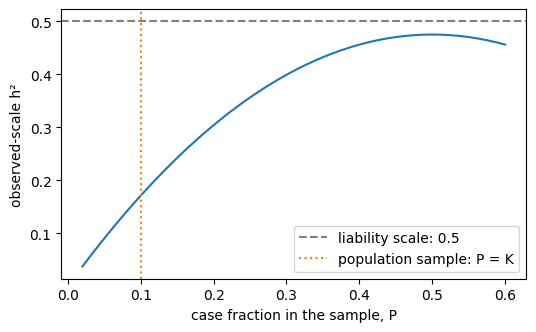

population sample 0.171, 1:1 study 0.475


In [14]:
from ltpred import liability_to_observed_h2

Ps = np.linspace(0.02, 0.6, 50)                # case fraction in the sample
h2_obs = [float(liability_to_observed_h2(H2, K, P)) for P in Ps]   # observed-scale h² for each P

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(Ps, h2_obs)
ax.axhline(H2, ls="--", color="grey", label="liability scale: 0.5")
ax.axvline(K, ls=":", color="C1", label="population sample: P = K")
ax.set_xlabel("case fraction in the sample, P")
ax.set_ylabel("observed-scale h²")
ax.legend()
plt.show()
print(f"population sample {float(liability_to_observed_h2(H2, K, None)):.3f}, "
      f"1:1 study {float(liability_to_observed_h2(H2, K, 0.5)):.3f}")

**Answer.** A population sample (P = K = 0.10) would report 0.171 and a 1:1 case/control
study 0.475, although the liability-scale h² is 0.5 in both. Passed to the scorer
unconverted, 0.171 is a legal h², so nothing raises an error, but it gives a calibration
slope of 2.3: Part A's too-timid scores. Convert first.

### Q11: Analysis note.

In at most 100 words: what does the family-history score estimate, what did it show in
this exercise, and what can it not establish? Cite one number from each part you did.

**Discuss** with your partner.

**Answer (example).** The score is the posterior mean of a person's genetic liability
given the relatives' diagnoses and ages, the incidence curve and a liability-scale h².
Its scale follows the h² you supply: at 0.8 instead of 0.5 the ranking held (correlation
0.52) but the calibration slope fell to 0.7 (A). Scored at 40, it predicted diagnosis by
70 with AUC 0.61, against 0.89 for the true genetic liability (B). It beat a yes/no
family history (AUC 0.61 vs 0.56, C). Parent–offspring pairs gave h² = 0.52 ± 0.07 (D),
which a population GWAS would report as 0.17 (E). The score is not a risk and cannot
supply its own h².

## Environment

In [15]:
import platform, scipy
print(f"Python {platform.python_version()}, NumPy {np.__version__}, "
      f"SciPy {scipy.__version__}, ltpred {ltpred.__version__}")

Python 3.10.20, NumPy 1.26.4, SciPy 1.15.3, ltpred 0.7.1


---
Part of [ATIG 2026](https://github.com/bvilhjal/ATIG_2026), teaching day
[24 September](https://github.com/bvilhjal/ATIG_2026/tree/main/teaching_days/2026-09-24).